# gsea-lite: A Reproducible Demonstration of ORA and Simplified GSEA

This notebook demonstrates the full `gsea-lite` workflow using the real example data included in this repository. It is designed as a small executable tutorial rather than a unit-test notebook.

The workflow shows that:

1. The package can be imported successfully.
2. Real input data can be loaded and inspected.
3. Significant genes for ORA are selected transparently.
4. ORA can be performed correctly.
5. Pathway-level multiple-testing correction is applied.
6. Simplified GSEA can be performed.
7. Results can be visualized and saved.
8. Inputs, parameters, outputs, and limitations are documented for reproducibility.

## 1. Environment and package import

Before running this notebook, install the package from the project root:

```bash
python -m pip install -e ".[dev]"
```

This section imports the public package API instead of redefining the algorithms inside the notebook.

In [3]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

import gsea_lite
from gsea_lite import (
    read_geo,
    read_gmt,
    extract_significant_genes,
    do_ora,
    bh_fdr_correction,
    generate_ranked_list,
    run_gsea,
    plot_barplot,
    plot_dotplot,
    plot_gsea_barplot,
)

print(f"gsea-lite version: {gsea_lite.__version__}")
print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"SciPy: {scipy.__version__}")

gsea-lite version: 0.1.0
Python: 3.12.12
NumPy: 2.4.6
pandas: 3.0.3
SciPy: 1.17.1


## 2. Locate project files

The notebook can be launched from either the project root or the `examples/` directory. The code below locates the project root by checking for `pyproject.toml` and the example data directory.

In [4]:
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (
        (candidate / "pyproject.toml").exists()
        and (candidate / "examples" / "example_data").exists()
    ):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. Start Jupyter from the project root "
        "or from the examples directory."
    )

geo_path = PROJECT_ROOT / "examples" / "example_data" / "GSE42568.top.table.tsv"
gmt_path = PROJECT_ROOT / "examples" / "example_data" / "h.all.v2026.1.Hs.symbols.gmt"
output_dir = PROJECT_ROOT / "results" / "notebook_gsea_lite"
output_dir.mkdir(parents=True, exist_ok=True)

assert geo_path.exists(), f"Missing GEO input file: {geo_path}"
assert gmt_path.exists(), f"Missing GMT input file: {gmt_path}"

print("Project root:", PROJECT_ROOT)
print("GEO input:", geo_path)
print("GMT input:", gmt_path)
print("Output directory:", output_dir)

Project root: /home/sherryxia/bio2503/gsea_lite
GEO input: /home/sherryxia/bio2503/gsea_lite/examples/example_data/GSE42568.top.table.tsv
GMT input: /home/sherryxia/bio2503/gsea_lite/examples/example_data/h.all.v2026.1.Hs.symbols.gmt
Output directory: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite


## 3. Load real expression and gene-set data

The expression file is a real GEO differential-expression table. The GMT file contains MSigDB Hallmark gene sets. The package readers validate required columns and parse the pathway database into reusable Python objects.

In [5]:
geo_data = read_geo(geo_path)
gene_sets = read_gmt(gmt_path)

print(f"Expression table shape: {geo_data.shape}")
print(f"Number of gene sets: {len(gene_sets)}")
display(geo_data.head())

first_pathway = next(iter(gene_sets))
print("Example pathway:", first_pathway)
print("First 10 genes in this pathway:", gene_sets[first_pathway][:10])

Expression table shape: (45118, 8)
Number of gene sets: 50


,ID,adj.P.Val,P.Value,t,B,logFC,Gene.symbol,Gene.title
0,230595_at,1.880000e-08,3.440000e-13,73.7,14.760161,4.82,PGM5-AS1,PGM5 antisense RNA 1
1,206209_s_at,8.880000e-07,3.250000e-11,43.0,13.543301,4.89,CA4,carbonic anhydrase 4
2,207537_at,1.760000e-06,9.670000e-11,37.8,13.087429,5.07,PFKFB1,"6-phosphofructo-2-kinase/fructose-2,6-biphosph..."
3,239523_at,1.960000e-06,1.440000e-10,36.0,12.903371,6.84,TUSC5,tumor suppressor candidate 5
4,1552519_at,2.260000e-06,2.070000e-10,34.5,12.724641,7.18,ACVR1C,activin A receptor type 1C


Example pathway: HALLMARK_ADIPOGENESIS
First 10 genes in this pathway: ['ABCA1', 'ABCB8', 'ACAA2', 'ACADL', 'ACADM', 'ACADS', 'ACLY', 'ACO2', 'ACOX1', 'ADCY6']


## 4. Inspect and validate input data

This notebook does not redo all preprocessing, because `read_geo()` already removes rows with missing required values. Still, a short validation summary makes the input quality visible to the reader.

In [6]:
required_columns = ["Gene.symbol", "logFC", "P.Value"]
if "adj.P.Val" in geo_data.columns:
    required_columns.append("adj.P.Val")

validation_summary = pd.DataFrame(
    {
        "metric": [
            "rows_after_read_geo",
            "unique_gene_symbols",
            "duplicated_gene_symbols",
            "missing_gene_symbols",
            "missing_logFC",
            "missing_P.Value",
        ],
        "value": [
            len(geo_data),
            geo_data["Gene.symbol"].nunique(),
            int(geo_data["Gene.symbol"].duplicated().sum()),
            int(geo_data["Gene.symbol"].isna().sum()),
            int(geo_data["logFC"].isna().sum()),
            int(geo_data["P.Value"].isna().sum()),
        ],
    }
)

print("Required columns present:", all(col in geo_data.columns for col in required_columns))
display(validation_summary)
display(geo_data[required_columns].describe(include="all"))

Required columns present: True


,metric,value
0,rows_after_read_geo,45118
1,unique_gene_symbols,21755
2,duplicated_gene_symbols,23363
3,missing_gene_symbols,0
4,missing_logFC,0
5,missing_P.Value,0


,Gene.symbol,logFC,P.Value,adj.P.Val
count,45118,45118.000000,4.511800e+04,4.511800e+04
unique,21755,NaN,NaN,NaN
top,YME1L1,NaN,NaN,NaN
freq,20,NaN,NaN,NaN
mean,NaN,0.020243,3.815405e-01,5.872623e-01
std,NaN,0.986063,3.279568e-01,3.011381e-01
min,NaN,-6.010000,3.440000e-13,1.880000e-08
25%,NaN,-0.265000,8.750000e-02,3.760000e-01
50%,NaN,0.000000,3.290000e-01,6.280000e-01
75%,NaN,0.161000,6.130000e-01,8.250000e-01


The expression table was validated before downstream enrichment analysis.

No missing values were found in required columns.
Duplicated gene symbols are expected because multiple probes may map to the same gene.

Only after input validation were ORA and GSEA performed.

## 5. Define ORA thresholds and selected genes

There are two different multiple-testing contexts in this workflow:

- `adj.P.Val` is a gene-level adjusted p-value from the differential-expression analysis.
- ORA `FDR` is a pathway-level adjusted p-value calculated after testing many gene sets.

For selecting significant genes before ORA, this notebook uses `adj.P.Val < 0.05` when the column is available. If a user's input table does not include `adj.P.Val`, the workflow falls back to raw `P.Value < 0.05` and reports that choice explicitly.

In [7]:
DEG_FDR_THRESH = 0.05
P_THRESH = 0.05
LFC_THRESH = 1.0
TOP_N = 10

if "adj.P.Val" in geo_data.columns:
    gene_p_column = "adj.P.Val"
    gene_p_threshold = DEG_FDR_THRESH
else:
    gene_p_column = "P.Value"
    gene_p_threshold = P_THRESH

significant_gene_table = geo_data[
    (geo_data[gene_p_column] < gene_p_threshold)
    & (geo_data["logFC"].abs() > LFC_THRESH)
].copy()

significant_gene_set = set(significant_gene_table["Gene.symbol"].dropna().unique())

print(f"Gene-level significance column: {gene_p_column}")
print(f"Gene-level threshold: {gene_p_column} < {gene_p_threshold}")
print(f"logFC threshold: abs(logFC) > {LFC_THRESH}")
print(f"Number of selected significant genes: {len(significant_gene_set)}")

display(
    significant_gene_table[
        ["Gene.symbol", "logFC", "P.Value"] + (["adj.P.Val"] if "adj.P.Val" in significant_gene_table.columns else [])
    ].head(10)
)

Gene-level significance column: adj.P.Val
Gene-level threshold: adj.P.Val < 0.05
logFC threshold: abs(logFC) > 1.0
Number of selected significant genes: 1894


,Gene.symbol,logFC,P.Value,adj.P.Val
0,PGM5-AS1,4.82,3.440000e-13,1.880000e-08
1,CA4,4.89,3.250000e-11,8.880000e-07
2,PFKFB1,5.07,9.670000e-11,1.760000e-06
3,TUSC5,6.84,1.440000e-10,1.960000e-06
4,ACVR1C,7.18,2.070000e-10,2.260000e-06
5,RBP4,9.67,4.170000e-10,3.800000e-06
6,HEPN1,5.69,7.030000e-10,5.490000e-06
7,LOC101930400,7.30,9.170000e-10,6.270000e-06
8,C14orf180,5.87,1.360000e-09,8.240000e-06
9,ATP1A2,5.68,1.680000e-09,8.770000e-06


## 6. Make the ORA background explicit

The hypergeometric test depends strongly on the background universe. In this package, `do_ora()` uses all measured genes in the expression table as the universe, then intersects each pathway with that measured universe before calculating pathway size. This avoids using the whole genome as a background when the experiment only measured a subset of genes.

For transparency, the cell below reports both all measured genes and the subset that appears in at least one GMT pathway.

In [8]:
measured_genes = set(geo_data["Gene.symbol"].dropna().unique())
all_gmt_genes = set().union(*(set(genes) for genes in gene_sets.values()))
measured_genes_in_gmt = measured_genes & all_gmt_genes

background_summary = pd.DataFrame(
    [
        {"background_component": "all measured genes used by do_ora", "count": len(measured_genes)},
        {"background_component": "unique genes in GMT database", "count": len(all_gmt_genes)},
        {"background_component": "measured genes also present in GMT", "count": len(measured_genes_in_gmt)},
        {"background_component": "selected significant genes", "count": len(significant_gene_set)},
    ]
)

display(background_summary)

,background_component,count
0,all measured genes used by do_ora,21755
1,unique genes in GMT database,4384
2,measured genes also present in GMT,4206
3,selected significant genes,1894


## 7. Run ORA

`do_ora()` currently selects significant genes internally using raw `P.Value` and `logFC` thresholds. To keep this tutorial aligned with the package implementation, the ORA run below uses the package default selection rule:

```text
P.Value < 0.05 and abs(logFC) > 1.0
```

The earlier `adj.P.Val` summary is included to clarify the difference between gene-level FDR and pathway-level FDR. If you want ORA to use `adj.P.Val` directly, `do_ora()` would need an additional argument for the gene-level p-value column.

In [9]:
package_sig_genes = extract_significant_genes(
    geo_data,
    p_thresh=P_THRESH,
    lfc_thresh=LFC_THRESH,
)

print(f"Significant genes selected by package ORA rule: {len(package_sig_genes)}")

ora_results = do_ora(
    geo_data,
    gene_sets,
    p_thresh=P_THRESH,
    lfc_thresh=LFC_THRESH,
)

print(f"ORA pathways tested: {len(ora_results)}")
display(ora_results.head())

Significant genes selected by package ORA rule: 4669
--- 背景基因库说明 ---
提取到全局背景基因 (Universe) 数量: 21755
提取到显著差异基因 (DEGs) 数量: 4669
原理解释: 仅使用在当前测序平台/微阵列中实际检测到的 21755 个基因作为超几何检验的背景，而不是整个人类基因组，能有效避免因技术偏倚导致的假阳性。
----------------------
ORA pathways tested: 50


,pathway,P.Value,Count,pathway_size,GeneRatio,hits_genes
0,HALLMARK_ADIPOGENESIS,2.451686e-28,111,191,0.023774,"LIFR,PGM1,CIDEA,COX7B,SNCG,DGAT1,NKIRAS1,GBE1,..."
1,HALLMARK_E2F_TARGETS,3.118319e-26,108,191,0.023131,"POLD1,SSRP1,BIRC5,ANP32E,LMNB1,PTTG1,MCM3,HMGB..."
2,HALLMARK_G2M_CHECKPOINT,8.517784e-23,101,186,0.021632,"SLC7A1,MNAT1,HNRNPU,BIRC5,TFDP1,LMNB1,PTTG1,MC..."
3,HALLMARK_INTERFERON_GAMMA_RESPONSE,1.274111e-18,97,194,0.020775,"PLSCR1,SRI,TAP1,SPPL2A,OASL,NLRC5,IFIH1,NAMPT,..."
4,HALLMARK_OXIDATIVE_PHOSPHORYLATION,6.014780e-14,84,181,0.017991,"CYB5A,IDH3B,COX5A,SUCLA2,ETFA,COX7B,ATP6V0E1,A..."


## 8. Apply pathway-level BH-FDR correction

ORA produces one raw p-value per pathway. Because many pathways are tested, the notebook applies Benjamini-Hochberg correction across pathway p-values and saves the adjusted result table.

In [10]:
if ora_results.empty:
    raise RuntimeError("ORA returned no results. Try relaxing P_THRESH or LFC_THRESH.")

ora_results = ora_results.copy()
ora_results["FDR"] = bh_fdr_correction(ora_results["P.Value"])
ora_results = ora_results[
    ["pathway", "P.Value", "FDR", "Count", "pathway_size", "GeneRatio", "hits_genes"]
].sort_values("FDR").reset_index(drop=True)

ora_csv = output_dir / "ora_results_fdr.csv"
ora_results.to_csv(ora_csv, index=False)

print("Saved ORA table to:", ora_csv)
display(ora_results.head(TOP_N))

Saved ORA table to: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite/ora_results_fdr.csv


,pathway,P.Value,FDR,Count,pathway_size,GeneRatio,hits_genes
0,HALLMARK_ADIPOGENESIS,2.451686e-28,1.225843e-26,111,191,0.023774,"LIFR,PGM1,CIDEA,COX7B,SNCG,DGAT1,NKIRAS1,GBE1,..."
1,HALLMARK_E2F_TARGETS,3.118319e-26,7.795797e-25,108,191,0.023131,"POLD1,SSRP1,BIRC5,ANP32E,LMNB1,PTTG1,MCM3,HMGB..."
2,HALLMARK_G2M_CHECKPOINT,8.517784e-23,1.419631e-21,101,186,0.021632,"SLC7A1,MNAT1,HNRNPU,BIRC5,TFDP1,LMNB1,PTTG1,MC..."
3,HALLMARK_INTERFERON_GAMMA_RESPONSE,1.274111e-18,1.592639e-17,97,194,0.020775,"PLSCR1,SRI,TAP1,SPPL2A,OASL,NLRC5,IFIH1,NAMPT,..."
4,HALLMARK_OXIDATIVE_PHOSPHORYLATION,6.014780e-14,6.014780e-13,84,181,0.017991,"CYB5A,IDH3B,COX5A,SUCLA2,ETFA,COX7B,ATP6V0E1,A..."
5,HALLMARK_FATTY_ACID_METABOLISM,2.060390e-13,1.716992e-12,74,154,0.015849,"PDHB,ACSL1,CA4,GLUL,G0S2,CPT2,ECHS1,HIBCH,CD36..."
6,HALLMARK_ESTROGEN_RESPONSE_LATE,3.068197e-12,2.191570e-11,85,195,0.018205,"TFAP2C,BLVRB,FOS,DNAJC1,MICB,CAV1,CPE,NRIP1,LL..."
7,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,4.285959e-12,2.678724e-11,85,196,0.018205,"FBLN5,PCOLCE2,SNTB1,VCAN,INHBA,ITGB1,SLIT2,MES..."
8,HALLMARK_UV_RESPONSE_DN,7.938490e-12,4.410272e-11,65,136,0.013922,"SYNJ2,ADD3,LTBP1,LAMC1,FBLN5,MAGI2,SRI,PIK3CD,..."
9,HALLMARK_MITOTIC_SPINDLE,4.632694e-11,2.316347e-10,83,197,0.017777,"FGD4,CDC42EP2,BIRC5,LMNB1,NCK1,RASA1,CSNK1D,PC..."


## 9. Visualize ORA results

The bar plot summarizes pathway significance using `-log10(FDR)`. The dot plot also shows gene ratio and hit count. Both figures are saved as PNG files.

In [11]:
barplot_path = output_dir / "ora_barplot.png"
dotplot_path = output_dir / "ora_dotplot.png"

plot_barplot(ora_results, top_n=TOP_N, output_path=barplot_path)
plot_dotplot(ora_results, top_n=TOP_N, output_path=dotplot_path)

print("Saved ORA bar plot to:", barplot_path)
print("Saved ORA dot plot to:", dotplot_path)

Saved ORA bar plot to: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite/ora_barplot.png
Saved ORA dot plot to: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite/ora_dotplot.png


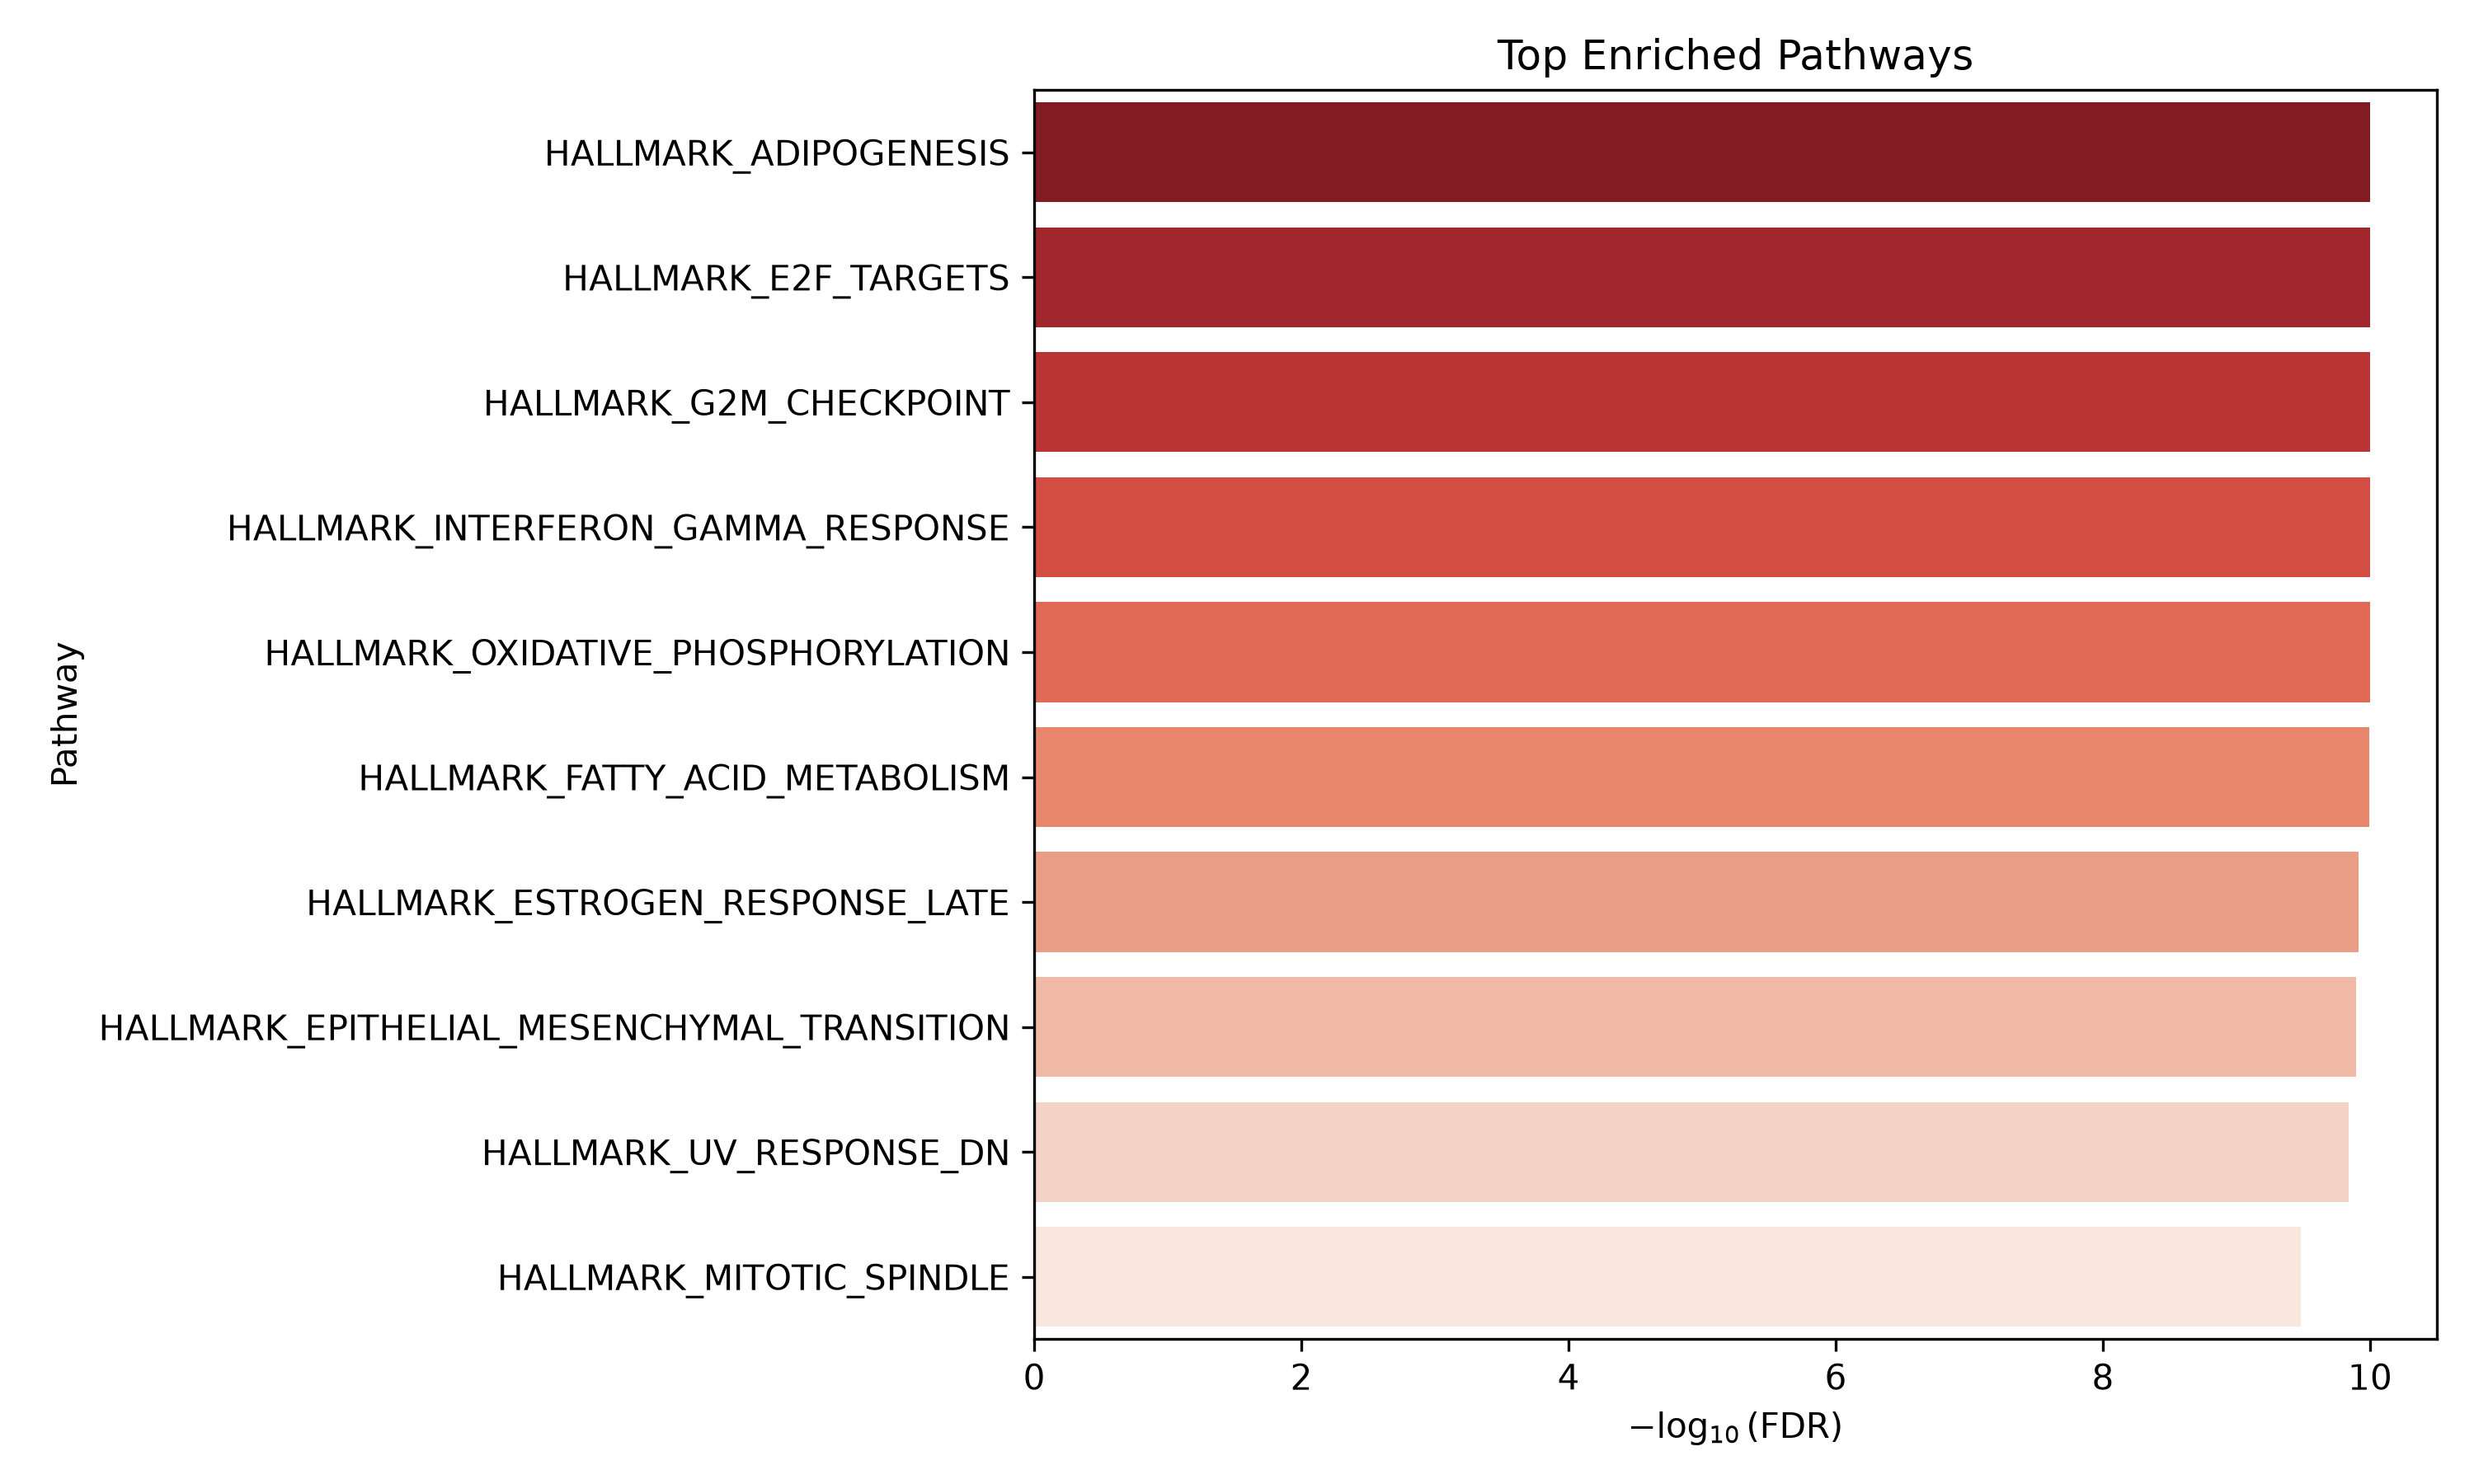

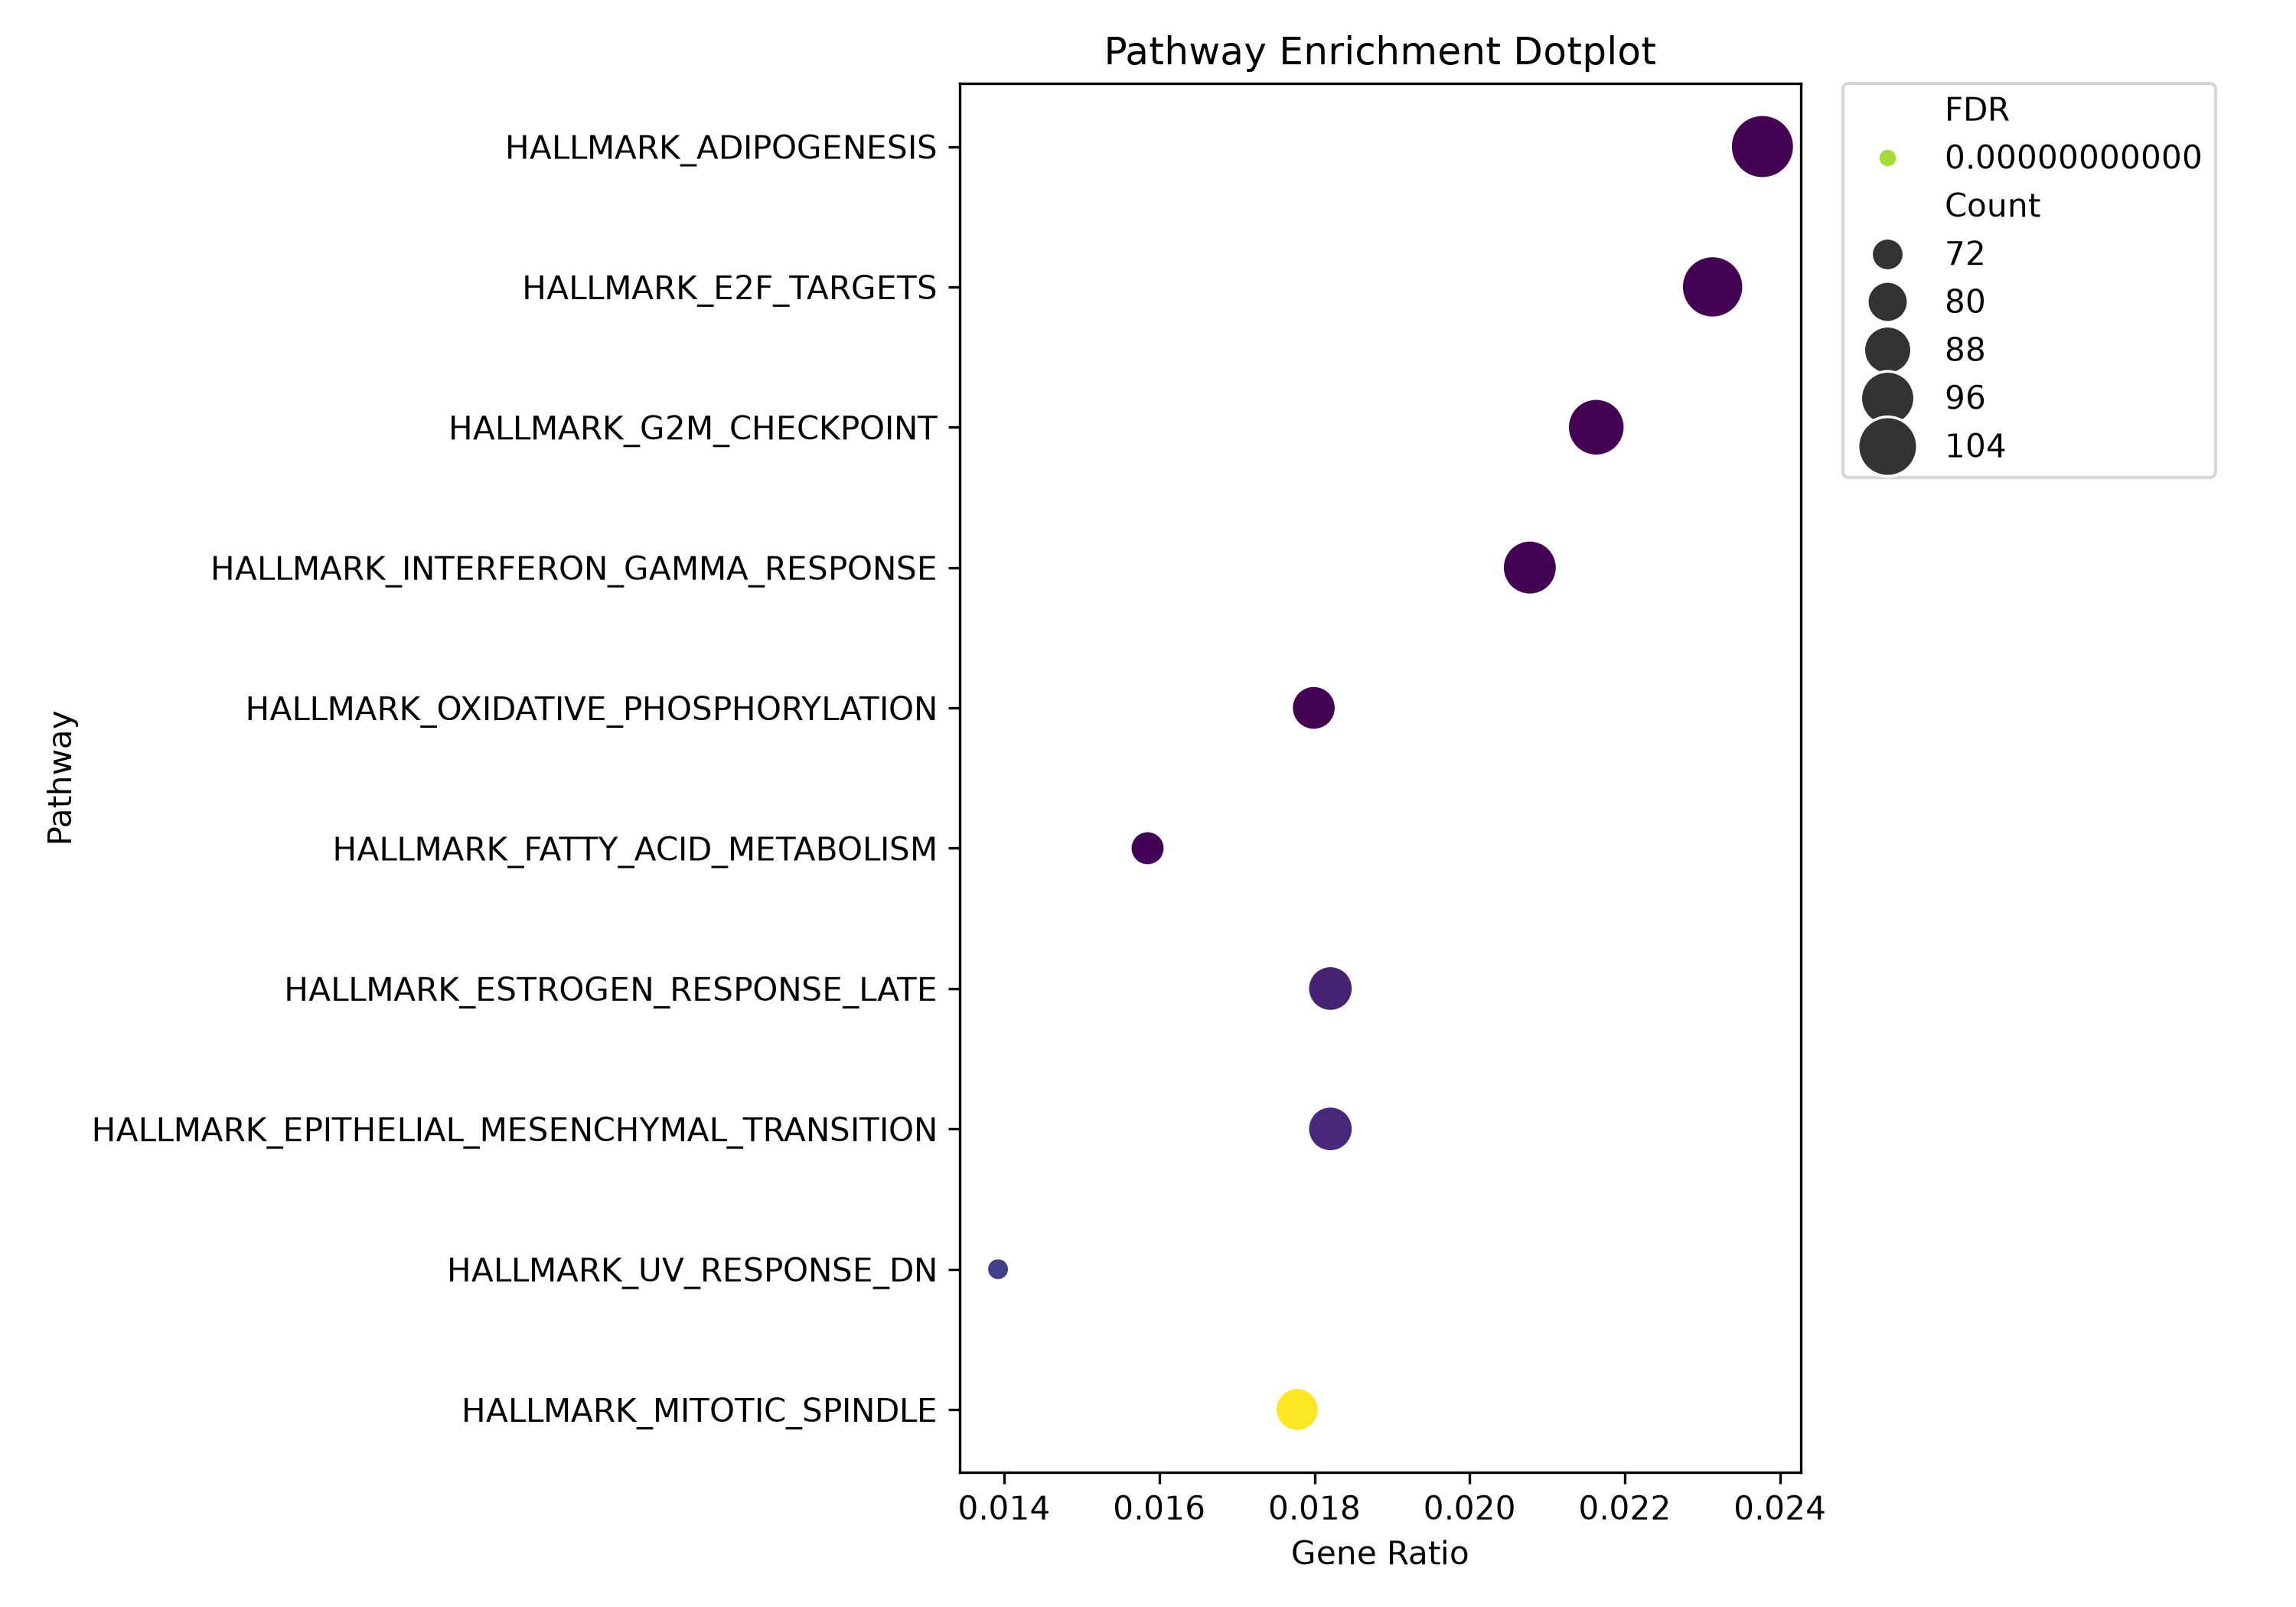

In [12]:
from IPython.display import Image, display

display(Image(filename=str(barplot_path)))
display(Image(filename=str(dotplot_path)))

## 10. Construct the ranked gene list

Simplified GSEA uses all genes rather than only significant genes. The package removes duplicate gene symbols by keeping the row with the largest absolute `logFC`, then ranks genes by `logFC` from high to low.

In [13]:
ranked_gene_list = generate_ranked_list(geo_data)

print(f"Ranked genes used for simplified GSEA: {len(ranked_gene_list)}")
display(ranked_gene_list.head(10))
display(ranked_gene_list.tail(10))

Ranked genes used for simplified GSEA: 21755


,Gene.symbol,logFC
0,RBP4,9.67
1,LEP,9.14
2,FABP4,8.83
3,THRSP,8.63
4,CIDEC,8.26
5,LPL,8.15
6,PLIN1,8.14
7,TIMP4,8.13
8,PLIN4,7.93
9,CD36,7.84


,Gene.symbol,logFC
21745,EZH2,-4.98
21746,GABRP,-4.99
21747,POU2AF1,-5.02
21748,CXCL10,-5.23
21749,RRM2,-5.36
21750,CDC20,-5.37
21751,SFN,-5.42
21752,FDCSP,-5.65
21753,UBD,-5.94
21754,LTF,-6.01


## 11. Run simplified GSEA

This package implements an educational simplified GSEA. It calculates an enrichment score (ES) from genes ranked by `logFC`. It does not implement the full Broad Institute GSEA workflow: no phenotype permutations, normalized enrichment score (NES), permutation-based nominal p-values, GSEA-specific FDR, or leading-edge analysis are calculated.

In [14]:
gsea_results = run_gsea(geo_data, gene_sets)

gsea_csv = output_dir / "gsea_results.csv"
gsea_results.to_csv(gsea_csv, index=False)

print("Saved GSEA table to:", gsea_csv)
display(gsea_results.head(TOP_N))

Saved GSEA table to: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite/gsea_results.csv


,Pathway,ES,Gene_Count
0,HALLMARK_INTERFERON_ALPHA_RESPONSE,-0.577004,97
1,HALLMARK_ADIPOGENESIS,0.547374,200
2,HALLMARK_E2F_TARGETS,-0.502725,200
3,HALLMARK_OXIDATIVE_PHOSPHORYLATION,0.495434,200
4,HALLMARK_INTERFERON_GAMMA_RESPONSE,-0.481726,200
5,HALLMARK_G2M_CHECKPOINT,-0.475203,200
6,HALLMARK_MYC_TARGETS_V2,-0.432673,58
7,HALLMARK_FATTY_ACID_METABOLISM,0.391964,158
8,HALLMARK_ALLOGRAFT_REJECTION,-0.353825,200
9,HALLMARK_UV_RESPONSE_DN,0.341662,144


## 12. Visualize simplified GSEA results

The plot below shows the pathways with the largest absolute enrichment scores. Positive ES indicates enrichment near the top of the ranked list; negative ES indicates enrichment near the bottom.

Saved GSEA plot to: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite/gsea_es_barplot.png


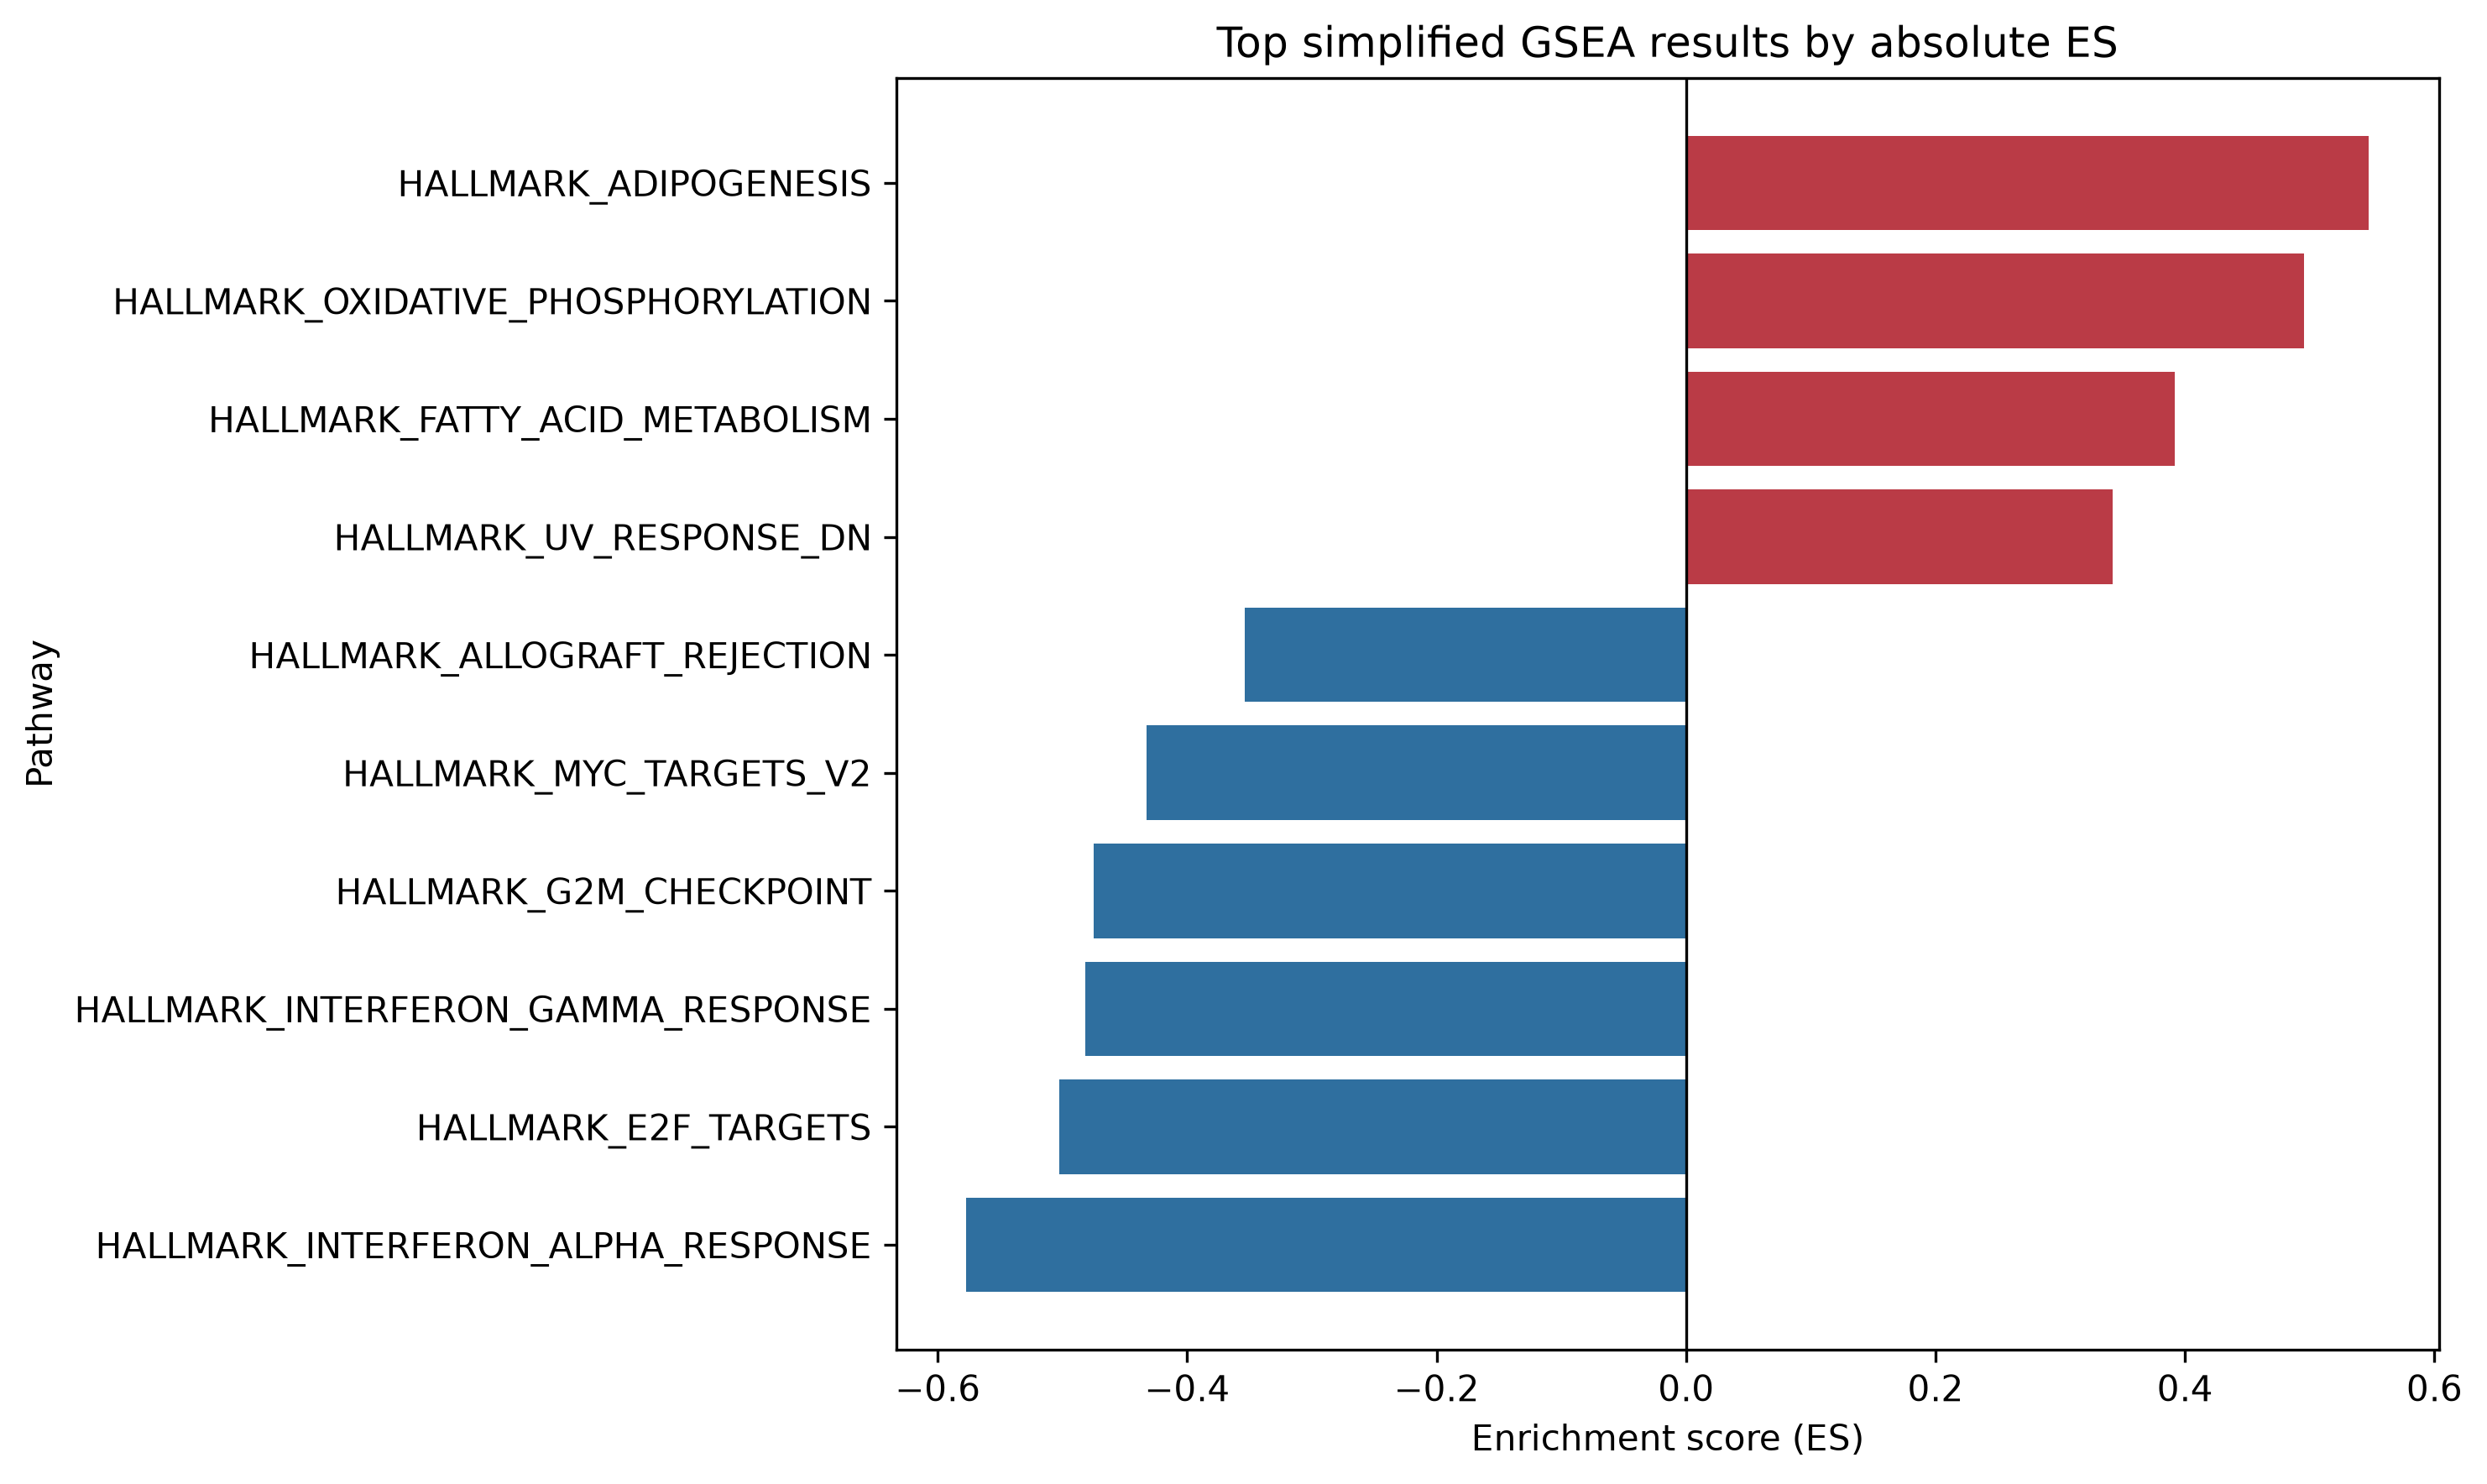

In [15]:
gsea_plot_path = output_dir / "gsea_es_barplot.png"

plot_gsea_barplot(gsea_results, top_n=TOP_N, output_path=gsea_plot_path)

from IPython.display import Image, display
display(Image(filename=str(gsea_plot_path)))

## 13. Results and interpretation

This section summarizes the main biological signals in the run. The exact values are calculated from the current inputs so the interpretation remains reproducible when thresholds or data change.

In [16]:
significant_ora = ora_results[ora_results["FDR"] < 0.05]
positive_gsea = gsea_results.sort_values("ES", ascending=False).head(5)
negative_gsea = gsea_results.sort_values("ES", ascending=True).head(5)

print(f"Genes analyzed after cleaning: {len(geo_data)} rows")
print(f"Unique measured genes: {len(measured_genes)}")
print(f"Significant genes selected by package ORA rule: {len(package_sig_genes)}")
print(f"Pathways tested by ORA: {len(ora_results)}")
print(f"ORA pathways with FDR < 0.05: {len(significant_ora)}")

print("\nTop ORA pathways by FDR:")
display(ora_results[["pathway", "P.Value", "FDR", "Count", "GeneRatio"]].head(5))

print("Top positively enriched simplified GSEA pathways:")
display(positive_gsea)

print("Top negatively enriched simplified GSEA pathways:")
display(negative_gsea)

top_ora_names = set(ora_results.head(10)["pathway"])
top_gsea_names = set(gsea_results.head(10)["Pathway"])
overlap = sorted(top_ora_names & top_gsea_names)

print("Overlap between top 10 ORA and top 10 simplified GSEA pathways:")
print(overlap if overlap else "No direct top-10 overlap in this run.")

Genes analyzed after cleaning: 45118 rows
Unique measured genes: 21755
Significant genes selected by package ORA rule: 4669
Pathways tested by ORA: 50
ORA pathways with FDR < 0.05: 42

Top ORA pathways by FDR:


,pathway,P.Value,FDR,Count,GeneRatio
0,HALLMARK_ADIPOGENESIS,2.451686e-28,1.225843e-26,111,0.023774
1,HALLMARK_E2F_TARGETS,3.118319e-26,7.795797e-25,108,0.023131
2,HALLMARK_G2M_CHECKPOINT,8.517784e-23,1.419631e-21,101,0.021632
3,HALLMARK_INTERFERON_GAMMA_RESPONSE,1.274111e-18,1.592639e-17,97,0.020775
4,HALLMARK_OXIDATIVE_PHOSPHORYLATION,6.014780e-14,6.014780e-13,84,0.017991


Top positively enriched simplified GSEA pathways:


,Pathway,ES,Gene_Count
1,HALLMARK_ADIPOGENESIS,0.547374,200
3,HALLMARK_OXIDATIVE_PHOSPHORYLATION,0.495434,200
7,HALLMARK_FATTY_ACID_METABOLISM,0.391964,158
9,HALLMARK_UV_RESPONSE_DN,0.341662,144
10,HALLMARK_PROTEIN_SECRETION,0.337165,96


Top negatively enriched simplified GSEA pathways:


,Pathway,ES,Gene_Count
0,HALLMARK_INTERFERON_ALPHA_RESPONSE,-0.577004,97
2,HALLMARK_E2F_TARGETS,-0.502725,200
4,HALLMARK_INTERFERON_GAMMA_RESPONSE,-0.481726,200
5,HALLMARK_G2M_CHECKPOINT,-0.475203,200
6,HALLMARK_MYC_TARGETS_V2,-0.432673,58


Overlap between top 10 ORA and top 10 simplified GSEA pathways:
['HALLMARK_ADIPOGENESIS', 'HALLMARK_E2F_TARGETS', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_G2M_CHECKPOINT', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION', 'HALLMARK_UV_RESPONSE_DN']


## 14. Methodological notes and limitations

- ORA depends on a thresholded significant-gene list. In this package implementation, the ORA function uses raw `P.Value` plus `abs(logFC)` thresholds to select genes.
- Pathway-level ORA p-values are corrected with BH-FDR after all pathway tests are collected.
- The ORA universe is based on measured genes in the expression table, not the whole genome.
- The simplified GSEA implementation reports ES only. It should be interpreted as an educational ranking-based enrichment score, not a full GSEA statistical result with NES, permutation p-values, or GSEA FDR.
- ORA and GSEA answer related but different questions, so their top pathways may not be identical.

## 15. Reproducibility summary

The final cell records input files, thresholds, generated outputs, and package versions.

In [17]:
summary = pd.DataFrame(
    [
        {"item": "package", "value": f"gsea-lite {gsea_lite.__version__}"},
        {"item": "python", "value": platform.python_version()},
        {"item": "geo_input", "value": str(geo_path)},
        {"item": "gmt_input", "value": str(gmt_path)},
        {"item": "ora_gene_p_column_used_by_package", "value": "P.Value"},
        {"item": "ora_gene_p_threshold", "value": P_THRESH},
        {"item": "ora_lfc_threshold", "value": LFC_THRESH},
        {"item": "selected_genes_package_rule", "value": len(package_sig_genes)},
        {"item": "ora_pathways_tested", "value": len(ora_results)},
        {"item": "ora_fdr_lt_0.05", "value": len(significant_ora)},
        {"item": "ora_table", "value": str(ora_csv)},
        {"item": "gsea_table", "value": str(gsea_csv)},
        {"item": "ora_barplot", "value": str(barplot_path)},
        {"item": "ora_dotplot", "value": str(dotplot_path)},
        {"item": "gsea_barplot", "value": str(gsea_plot_path)},
    ]
)

summary_csv = output_dir / "workflow_summary.csv"
summary.to_csv(summary_csv, index=False)

print("Saved workflow summary to:", summary_csv)
display(summary)

Saved workflow summary to: /home/sherryxia/bio2503/gsea_lite/results/notebook_gsea_lite/workflow_summary.csv


,item,value
0,package,gsea-lite 0.1.0
1,python,3.12.12
2,geo_input,/home/sherryxia/bio2503/gsea_lite/examples/exa...
3,gmt_input,/home/sherryxia/bio2503/gsea_lite/examples/exa...
4,ora_gene_p_column_used_by_package,P.Value
5,ora_gene_p_threshold,0.05
6,ora_lfc_threshold,1.0
7,selected_genes_package_rule,4669
8,ora_pathways_tested,50
9,ora_fdr_lt_0.05,42


## 16. Generated files

After running all cells, the notebook writes these files under `results/notebook_demo/`:

- `ora_results_fdr.csv`: ORA pathway table with raw p-values and BH-FDR values.
- `ora_barplot.png`: top ORA pathways ranked by FDR significance.
- `ora_dotplot.png`: top ORA pathways with gene ratio, hit count, and FDR.
- `gsea_results.csv`: simplified GSEA enrichment scores sorted by absolute ES.
- `gsea_es_barplot.png`: top simplified GSEA pathways by absolute ES.
- `workflow_summary.csv`: input paths, parameters, output paths, and version information.